<a href="https://colab.research.google.com/github/AlexitoFernandez/practicas-google-colab/blob/unidad-3/Practica_4_Arboles_De_Decisi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#"Machine Learning"
##Unidad III
### **Practica 4 - Árboles de Decisión Lending Club**

Alumno: Jorge Alejandro Fernández De Los Santos.

Facilitador: José Gabriel Rodríguez Rivas.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import gdown

# Cargar datos
file_id = '1HBU_efbbPg378pZvLZ1AtvRFAKrEFsob'
output = 'lending_club_2007_2011_6_states.csv'
gdown.download(id=file_id, output=output, quiet=False)
prestamos_df= pd.read_csv(output)
print(prestamos_df.head())

Downloading...
From: https://drive.google.com/uc?id=1HBU_efbbPg378pZvLZ1AtvRFAKrEFsob
To: /content/lending_club_2007_2011_6_states.csv
100%|██████████| 7.01M/7.01M [00:00<00:00, 107MB/s]


   loan_amnt  funded_amnt  funded_amnt_inv       term  int_rate  installment  \
0       2400         2400           2400.0  36 months     15.96        84.33   
1      10000        10000          10000.0  36 months     13.49       339.31   
2       3000         3000           3000.0  36 months     18.64       109.43   
3       5600         5600           5600.0  60 months     21.28       152.39   
4       5375         5375           5350.0  60 months     12.69       121.45   

  grade sub_grade            emp_title emp_length  ... application_type  \
0     C        C5                  NaN  10+ years  ...       Individual   
1     C        C1  AIR RESOURCES BOARD  10+ years  ...       Individual   
2     E        E1      MKC Accounting     9 years  ...       Individual   
3     F        F2                  NaN    4 years  ...       Individual   
4     B        B5            Starbucks   < 1 year  ...       Individual   

   acc_now_delinq chargeoff_within_12_mths delinq_amnt pub_rec_bankr

In [13]:
#Transformación de datos
if 'grade' in prestamos_df.columns: prestamos_df['grade_code'] = prestamos_df['grade'].factorize()[0]
if 'purpose' in prestamos_df.columns: prestamos_df['purpose_code'] = prestamos_df['purpose'].factorize()[0]
if 'addr_state' in prestamos_df.columns: prestamos_df['addr_state_code'] = prestamos_df['addr_state'].factorize()[0]
if 'home_ownership' in prestamos_df.columns: prestamos_df['home_ownership_code'] = prestamos_df['home_ownership'].factorize()[0]
print("Datos transformados.")

#Los meses al estar en stack, se transforman de texto a número y después se dividen en 12 para transformarlos a años
prestamos_df['loan_term_year'] = prestamos_df['term'].str.extract(r'(\d+)').astype(int) / 12

#La Regresión Logística es un clasificador binario, por lo que necesita convertir estas categorías en algo que pueda medir
prestamos_df['repaid'] = prestamos_df['loan_status'].apply(lambda x: 1 if x == 'Fully Paid' else 0)

# Selección de variables predictoras
X = prestamos_df[['funded_amnt', 'loan_term_year', 'int_rate', 'grade_code',
                  'purpose_code', 'addr_state_code', 'home_ownership_code',
                  'annual_inc', 'dti', 'revol_util', 'pub_rec_bankruptcies']]

# Variable objetivo o variable a predecir
y = prestamos_df["repaid"]

Datos transformados.


In [14]:
#Stratify sirve para mantener la misma proporción de clases en ambos conjuntos
#División del dataset (60% entrenamiento, 40% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size= 0.4, stratify=y )

#Verificación de formas
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11944, 11), (7964, 11), (11944,), (7964,))

In [15]:
# Crear el modelo de árbol de clasificación
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
# Entrenar el modelo
tree_model.fit(X_train, y_train)
# Precisión del modelo en la fase de entrenamiento
print("Precision del clasificador en fase de entrenamiento", tree_model.score(X_train, y_train))

Precision del clasificador en fase de entrenamiento 0.8534829202947086


In [16]:
# Hacer predicciones con los datos de prueba
y_pred = tree_model.predict(X_test)
# Crear un informe de texto que muestre las principales métricas de clasificación
print("\nReporte de métricas del clasificador de Arboles de Decisión: \n",
classification_report(y_test, y_pred, target_names=["No Pagado", "Pagado"]))
print(f'\nMatriz Confusion de Arboles de Decisión:\n', confusion_matrix(y_test, y_pred ))


Reporte de métricas del clasificador de Arboles de Decisión: 
               precision    recall  f1-score   support

   No Pagado       0.38      0.01      0.02      1177
      Pagado       0.85      1.00      0.92      6787

    accuracy                           0.85      7964
   macro avg       0.62      0.50      0.47      7964
weighted avg       0.78      0.85      0.79      7964


Matriz Confusion de Arboles de Decisión:
 [[  11 1166]
 [  18 6769]]


In [17]:
# Crear modelo 2 con balanceo de clases
tree_model2 = DecisionTreeClassifier(criterion='gini', max_depth=5, class_weight='balanced', random_state=42, )
# Entrenar el modelo
tree_model2.fit(X_train, y_train)
# Realizar fase de pruena
y_pred2 = tree_model2.predict(X_test)
# Evaluar el modelo
print("\nReporte de métricas del clasificador de Arboles de Decisión: \n",
classification_report(y_test, y_pred2, target_names=["No Pagado", "Pagado"]))
print("\n Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred2))


Reporte de métricas del clasificador de Arboles de Decisión: 
               precision    recall  f1-score   support

   No Pagado       0.22      0.57      0.32      1177
      Pagado       0.90      0.65      0.75      6787

    accuracy                           0.64      7964
   macro avg       0.56      0.61      0.54      7964
weighted avg       0.80      0.64      0.69      7964


 Matriz de Confusión:
[[ 674  503]
 [2377 4410]]


In [18]:
# Crear modelo 3 con balanceo de clases y max_depth (profundidad del árbol)
tree_model3 = DecisionTreeClassifier(criterion='gini', max_depth=7, class_weight='balanced', random_state=42,)
# Entrenar el modelo
tree_model3.fit(X_train, y_train)
# Realizar fase de prueba
y_pred3 = tree_model3.predict(X_test)
# Evaluar el modelo de prueba
print("\nReporte de métricas del clasificador de Arboles de Decisión: \n",
classification_report(y_test, y_pred3, target_names=["No Pagado", "Pagado"]))
print("\n Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred3))


Reporte de métricas del clasificador de Arboles de Decisión: 
               precision    recall  f1-score   support

   No Pagado       0.20      0.69      0.31      1177
      Pagado       0.91      0.53      0.67      6787

    accuracy                           0.55      7964
   macro avg       0.56      0.61      0.49      7964
weighted avg       0.80      0.55      0.62      7964


 Matriz de Confusión:
[[ 816  361]
 [3208 3579]]


In [20]:
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt
model_columns = ['funded_amnt', 'loan_term_year', "int_rate", "grade_code", 'purpose_code', 'addr_state_code',
'home_ownership_code', 'annual_inc', 'dti', 'revol_util',
'pub_rec_bankruptcies']
# Visualizar el árbol en texto
print(export_text(tree_model3, feature_names=model_columns))

|--- int_rate <= 11.61
|   |--- int_rate <= 8.43
|   |   |--- annual_inc <= 58272.00
|   |   |   |--- revol_util <= 20.45
|   |   |   |   |--- revol_util <= 5.35
|   |   |   |   |   |--- annual_inc <= 34500.00
|   |   |   |   |   |   |--- annual_inc <= 26296.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- annual_inc >  26296.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- annual_inc >  34500.00
|   |   |   |   |   |   |--- annual_inc <= 54900.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- annual_inc >  54900.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- revol_util >  5.35
|   |   |   |   |   |--- addr_state_code <= 1.50
|   |   |   |   |   |   |--- annual_inc <= 54980.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- annual_inc >  54980.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- addr_state_code >  1.50
|   |   |   |   |   |   |--- dti <= 11.9

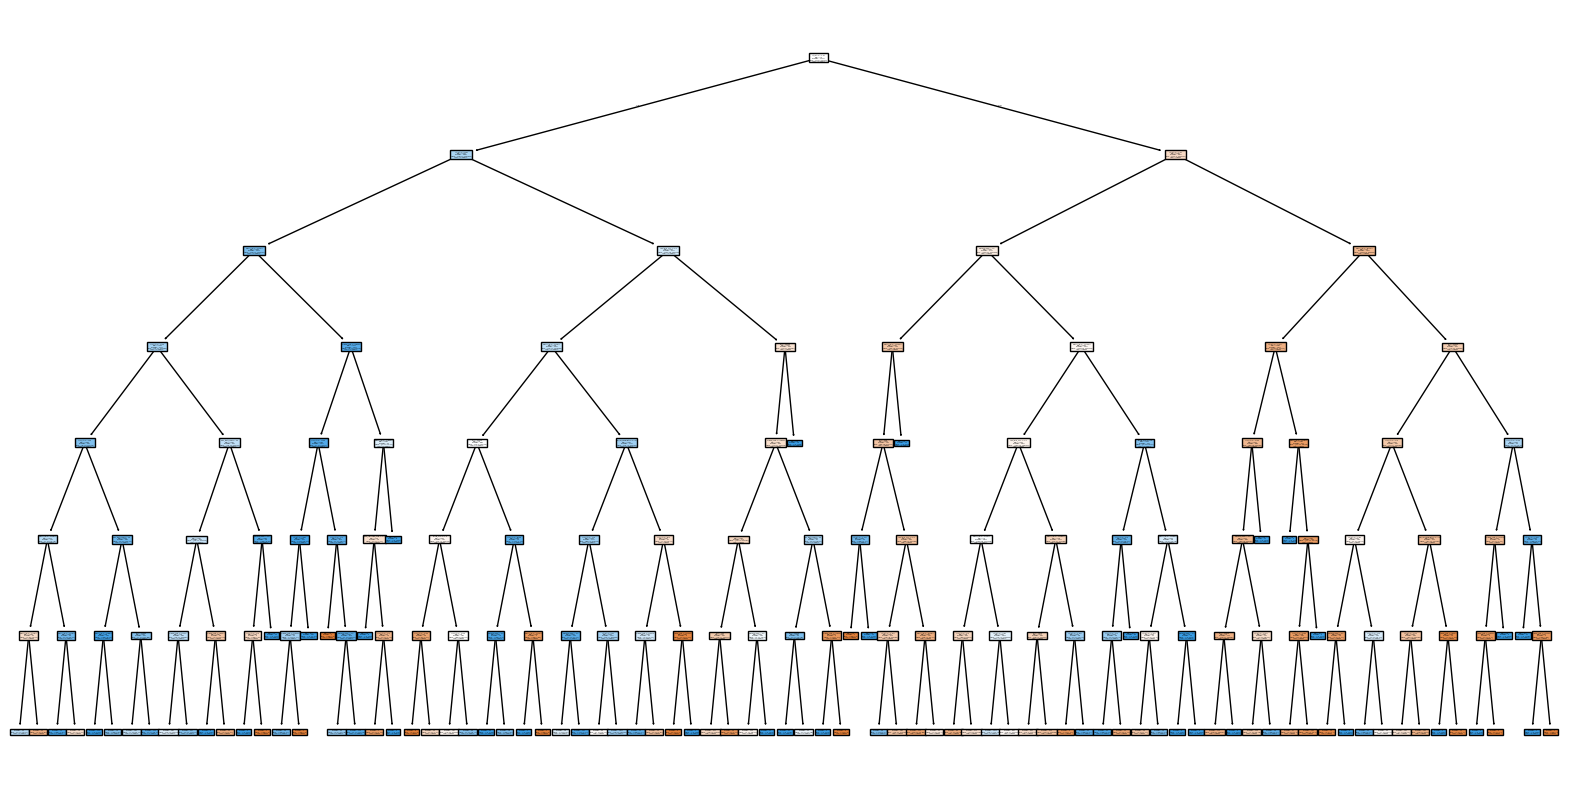

In [21]:
# Graficar el árbol
plt.figure(figsize=(20, 10))
plot_tree(tree_model3, feature_names=model_columns, class_names=['Pagado', 'No Pagado'], filled=True)
plt.show()

In [22]:
#Visualizar la importancia de las características
importancia_caracteristicas = pd.DataFrame({
'Caracteristica': model_columns,
'Importancia': tree_model3.feature_importances_
}).sort_values(by='Importancia', ascending=False)
print("\nImportancia de las características:")
print(importancia_caracteristicas)


Importancia de las características:
          Caracteristica  Importancia
2               int_rate     0.497094
7             annual_inc     0.158270
9             revol_util     0.100863
8                    dti     0.063899
4           purpose_code     0.052549
1         loan_term_year     0.046450
0            funded_amnt     0.040560
5        addr_state_code     0.015306
10  pub_rec_bankruptcies     0.011466
3             grade_code     0.010813
6    home_ownership_code     0.002731


In [23]:
# Graficar importancias con Plotly
import plotly.express as px
fig4 = px.bar(importancia_caracteristicas, x="Caracteristica", y="Importancia",
title="Importancia de características",
text_auto=".3f", color="Caracteristica")
fig4.update_layout(width=800, height=600)
fig4.show()

In [24]:
#Busqueda de los mejores parametros
from sklearn.model_selection import GridSearchCV
param_grid = {
'criterion': ['gini', 'entropy'],
'max_depth': [5, 7, 10, None],
'min_samples_split': [2, 5, 10, 20],
'min_samples_leaf': [1, 2, 5, 10],
'class_weight': [None, 'balanced'],
'ccp_alpha': [0.0, 0.001, 0.01]
}
grid_search = GridSearchCV(
DecisionTreeClassifier(random_state=42),
param_grid,
scoring='recall_macro',
cv=5,
n_jobs=-1,
verbose=2
)
# o 'f2' si te interesa más los impagos
grid_search.fit(X_train, y_train)
print("Mejores parámetros:", grid_search.best_params_)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Mejores parámetros: {'ccp_alpha': 0.001, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [25]:
# Evaluación del mejor modelo
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nReporte de Clasificación (modelo optimizado para detectar impagos):\n")
print(classification_report(y_test, y_pred))
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))


Reporte de Clasificación (modelo optimizado para detectar impagos):

              precision    recall  f1-score   support

           0       0.22      0.64      0.32      1177
           1       0.91      0.60      0.72      6787

    accuracy                           0.60      7964
   macro avg       0.56      0.62      0.52      7964
weighted avg       0.80      0.60      0.66      7964

Matriz de Confusión:
[[ 755  422]
 [2748 4039]]
